# GoEmotions Exploration

- github: https://github.com/google-research/google-research/tree/master/goemotions 
- paper: https://arxiv.org/pdf/2005.00547 

In [29]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "full_dataset"
BERT_DIR = ROOT / "models" / "bert"

DATA_DIR.mkdir(parents=True, exist_ok=True)
BERT_DIR.mkdir(parents=True, exist_ok=True)

ROOT, DATA_DIR, BERT_DIR

(PosixPath('/Users/amy/Documents/github/go-emotions-explore'),
 PosixPath('/Users/amy/Documents/github/go-emotions-explore/data/full_dataset'),
 PosixPath('/Users/amy/Documents/github/go-emotions-explore/models/bert'))

## Download Data

In [44]:
from urllib.request import urlretrieve

urls = [
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_1.csv",
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv",
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_3.csv",
]

for url in urls:
    target = DATA_DIR / url.rsplit("/", 1)[-1]
    if not target.exists():
        print(f"Downloading {target.name}")
        urlretrieve(url, target)
    else:
        print(f"Already present: {target.name}")

Already present: goemotions_1.csv
Already present: goemotions_2.csv
Already present: goemotions_3.csv


## BERT Repo / Model Assets

In [45]:
# Clone the BERT code repository if needed.
!test -d ../models/bert/google-research-bert || git clone https://github.com/google-research/bert ../models/bert/google-research-bert

# Hugging Face fallback examples:
# !mkdir -p ../models/bert/bert-base-uncased
# !curl -L https://huggingface.co/google-bert/bert-base-uncased/resolve/main/config.json -o ../models/bert/bert-base-uncased/config.json
# !curl -L https://huggingface.co/google-bert/bert-base-uncased/resolve/main/vocab.txt -o ../models/bert/bert-base-uncased/vocab.txt
# !curl -L https://huggingface.co/google-bert/bert-base-uncased/resolve/main/model.safetensors -o ../models/bert/bert-base-uncased/model.safetensors

## Load Raw Annotations

In [3]:
csv_paths = sorted(DATA_DIR.glob("goemotions_*.csv"))
csv_paths

[PosixPath('/Users/amy/Documents/github/go-emotions-explore/data/full_dataset/goemotions_1.csv'),
 PosixPath('/Users/amy/Documents/github/go-emotions-explore/data/full_dataset/goemotions_2.csv'),
 PosixPath('/Users/amy/Documents/github/go-emotions-explore/data/full_dataset/goemotions_3.csv')]

In [4]:
raw = pd.concat((pd.read_csv(path) for path in csv_paths), ignore_index=True)
raw.shape

(211225, 37)

In [5]:
raw.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,">sexuality shouldn’t be a grouping category It makes you different from othet ppl so imo it fits the definition of ""grouping""",eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Falcon.",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [6]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 37 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   text                  211225 non-null  str    
 1   id                    211225 non-null  str    
 2   author                211225 non-null  str    
 3   subreddit             211225 non-null  str    
 4   link_id               211225 non-null  str    
 5   parent_id             211225 non-null  str    
 6   created_utc           211225 non-null  float64
 7   rater_id              211225 non-null  int64  
 8   example_very_unclear  211225 non-null  bool   
 9   admiration            211225 non-null  int64  
 10  amusement             211225 non-null  int64  
 11  anger                 211225 non-null  int64  
 12  annoyance             211225 non-null  int64  
 13  approval              211225 non-null  int64  
 14  caring                211225 non-null  int64  
 15  confusion  

## Basic Data Checks

In [7]:
summary = {
    "rows": len(raw),
    "columns": raw.shape[1],
    "unique_text": raw["text"].nunique() if "text" in raw else np.nan,
    "unique_ids": raw["id"].nunique() if "id" in raw else np.nan,
    "duplicate_rows": raw.duplicated().sum(),
}
summary

{'rows': 211225,
 'columns': 37,
 'unique_text': 57732,
 'unique_ids': 58011,
 'duplicate_rows': np.int64(0)}

In [8]:
raw.isna().sum().sort_values(ascending=False).head(20)

text              0
disapproval       0
embarrassment     0
excitement        0
fear              0
gratitude         0
grief             0
joy               0
love              0
nervousness       0
optimism          0
pride             0
realization       0
relief            0
remorse           0
sadness           0
surprise          0
disgust           0
disappointment    0
id                0
dtype: int64

In [15]:
dupe_texts = (
    raw.groupby("text")["id"]
    .nunique()
    .reset_index(name="num_ids")
    .query("num_ids > 1")
    .sort_values("num_ids", ascending=False)
)

dupe_texts.head(20)

,text,num_ids
38016,Thank you.,15
37874,Thank you!,11
11378,Happy cake day!,9
45972,Weird flex but ok,7
17054,I like it,6
10403,Good luck!,6
17314,I love [NAME],6
52314,[NAME],6
17065,I like it!,5
37566,Thank you :),5


## Label Columns

GoEmotions stores emotion labels as one-hot columns. The metadata columns below are excluded from the label list.

In [9]:
metadata_cols = {
    "text", "id", "author", "subreddit", "link_id", "parent_id", "created_utc",
    "rater_id", "example_very_unclear"
}
label_cols = [col for col in raw.columns if col not in metadata_cols]
label_cols, len(label_cols)

(['admiration',
  'amusement',
  'anger',
  'annoyance',
  'approval',
  'caring',
  'confusion',
  'curiosity',
  'desire',
  'disappointment',
  'disapproval',
  'disgust',
  'embarrassment',
  'excitement',
  'fear',
  'gratitude',
  'grief',
  'joy',
  'love',
  'nervousness',
  'optimism',
  'pride',
  'realization',
  'relief',
  'remorse',
  'sadness',
  'surprise',
  'neutral'],
 28)

In [10]:
label_counts = raw[label_cols].sum().sort_values(ascending=False)
label_counts

neutral           55298
approval          17620
admiration        17131
annoyance         13618
gratitude         11625
disapproval       11424
curiosity          9692
amusement          9245
realization        8785
optimism           8715
disappointment     8469
love               8191
anger              8084
joy                7983
confusion          7359
sadness            6758
caring             5999
excitement         5629
surprise           5514
disgust            5301
desire             3817
fear               3197
remorse            2525
embarrassment      2476
nervousness        1810
pride              1302
relief             1289
grief               673
dtype: int64

## Annotator Coverage

In [11]:
annotator_counts = raw["rater_id"].value_counts().rename_axis("rater_id").reset_index(name="num_annotations")
annotator_counts.describe()

,rater_id,num_annotations
count,82.000000,82.000000
mean,40.500000,2575.914634
std,23.815261,2306.271590
min,0.000000,1.000000
25%,20.250000,541.500000
50%,40.500000,2069.000000
75%,60.750000,4113.000000
max,81.000000,10508.000000


In [12]:
annotations_per_example = raw.groupby("id")["rater_id"].nunique()
annotations_per_example.describe()

count    58011.000000
mean         3.641120
std          0.935532
min          1.000000
25%          3.000000
50%          3.000000
75%          5.000000
max          5.000000
Name: rater_id, dtype: float64

## Agreement Starter

Converts each row into a tuple of selected labels, then measures the most common label-set share per example.

In [16]:
def selected_labels(row):
    return tuple(label for label in label_cols if row[label] == 1)

In [18]:
raw["label_set"] = raw.apply(selected_labels, axis=1)

raw["label_set"].head(20)

0                    (sadness,)
1                            ()
2                    (neutral,)
3                       (love,)
4                    (neutral,)
5                  (gratitude,)
6                (disapproval,)
7                  (amusement,)
8                  (amusement,)
9                  (amusement,)
10                   (neutral,)
11            (disappointment,)
12                   (neutral,)
13    (disappointment, disgust)
14                   (neutral,)
15      (admiration, gratitude)
16                   (neutral,)
17               (realization,)
18                (admiration,)
19                 (annoyance,)
Name: label_set, dtype: object

In [19]:
agreement = (
    raw.groupby("id")["label_set"]
    .agg(num_annotations="size", top_label_set_count=lambda s: s.value_counts().iloc[0])
    .reset_index()
)

agreement.head(20)

,id,num_annotations,top_label_set_count
0,eczazk6,2,2
1,eczb07q,2,2
2,eczb4bm,3,3
3,eczb527,3,2
4,eczb6r7,5,2
5,eczb770,4,1
6,eczbbmd,3,2
7,eczbbwt,5,2
8,eczbdg4,3,3
9,eczbe89,5,1


In [20]:
agreement["percentage_agreement"] = agreement["top_label_set_count"] / agreement["num_annotations"]
agreement.describe()

,num_annotations,top_label_set_count,percentage_agreement
count,58011.000000,58011.000000,58011.000000
mean,3.641120,1.944717,0.566349
std,0.935532,0.728087,0.239197
min,1.000000,1.000000,0.200000
25%,3.000000,1.000000,0.333333
50%,3.000000,2.000000,0.666667
75%,5.000000,2.000000,0.666667
max,5.000000,5.000000,1.000000


In [22]:
raw.merge(agreement, on="id").sort_values("percentage_agreement",ascending=False).head(20)[
    ["id", "text", "rater_id", "label_set", "num_annotations", "percentage_agreement"]
]

,id,text,rater_id,label_set,num_annotations,percentage_agreement
105612,edvwdov,"It's interesting that [NAME] said [NAME] was his teacher on playing doomfist. Actually in mid 2017 [NAME] was one of, if not the best doomfist in China",39,"(neutral,)",3,1.0
86406,edyki2a,they were very hot for me half way in the year now diamonds seem dead opened 200 packs last week got 1 diamond,51,"(neutral,)",3,1.0
86431,edepc9e,Thanks a bunch <3,78,"(gratitude,)",3,1.0
86433,eddbxp3,The absolute worst!,37,"(disgust,)",3,1.0
86438,edtuuu6,1. Left tiddy 2. Right tiddy,52,"(neutral,)",5,1.0
86458,ef1mie3,Thankyou! :),61,"(gratitude,)",3,1.0
86493,eeux42y,"It wouldn't interest me at all, unfortunately.",40,"(neutral,)",3,1.0
86496,edw9w77,"There can be, but I meant the consequences of murdering someone in broad daylight.",16,"(neutral,)",3,1.0
86502,eelp0it,This is awesome!,67,"(admiration,)",3,1.0
86516,eezlt57,Thanks man! Helped me out quite a bit.,20,"(gratitude,)",5,1.0


## Interrater Correlation

In [27]:
def interrater_corr_for_label(df, label_col):
    rater_corrs = []

    for rater_id, rater_rows in df.groupby("rater_id"):
        rater_scores = rater_rows.set_index("id")[label_col]

        other_scores = (
            df[
                df["id"].isin(rater_scores.index)
                & (df["rater_id"] != rater_id)
            ]
            .groupby("id")[label_col]
            .mean()
        )

        shared_ids = rater_scores.index.intersection(other_scores.index)
        x = rater_scores.loc[shared_ids]
        y = other_scores.loc[shared_ids]

        if len(shared_ids) > 1 and x.nunique() > 1 and y.nunique() > 1:
            corr, _ = spearmanr(x, y)
            if not np.isnan(corr):
                rater_corrs.append(corr)

    return np.mean(rater_corrs) if rater_corrs else np.nan

In [32]:
metadata_cols = {
    "text", "id", "author", "subreddit", "link_id", "parent_id",
    "created_utc", "rater_id", "example_very_unclear"
}

label_cols = [
    col for col in raw.columns
    if col not in metadata_cols
    and pd.api.types.is_numeric_dtype(raw[col])
]

# Frequency = number of examples where at least one rater selected the emotion.
emotion_freq = raw.groupby("id")[label_cols].max().sum()

In [33]:
emotion_corr = pd.Series({
    label: interrater_corr_for_label(raw, label)
    for label in label_cols
})

emotion_corr.head(20)

admiration        0.441533
amusement         0.515182
anger             0.303921
annoyance         0.204505
approval          0.191327
caring            0.295278
confusion         0.277731
curiosity         0.358469
desire            0.270627
disappointment    0.203212
disapproval       0.231230
disgust           0.222776
embarrassment     0.206558
excitement        0.232002
fear              0.377112
gratitude         0.579386
grief             0.206544
joy               0.316516
love              0.543191
nervousness       0.130536
dtype: float64

In [34]:
plot_df = (
    pd.DataFrame({
        "emotion": emotion_freq.index,
        "frequency": emotion_freq.values,
        "interrater_corr": emotion_corr.loc[emotion_freq.index].values,
    })
    .sort_values("frequency", ascending=False)
)

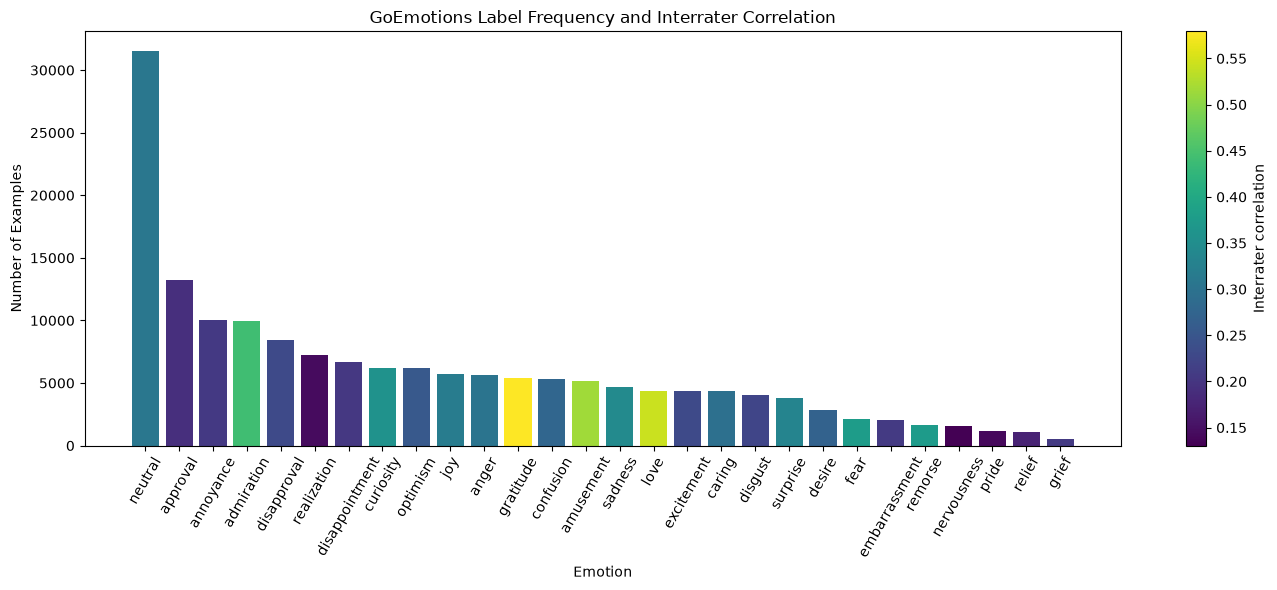

In [36]:
fig, ax = plt.subplots(figsize=(14, 6))

norm = plt.Normalize(
    plot_df["interrater_corr"].min(),
    plot_df["interrater_corr"].max()
)

cmap = plt.cm.viridis
colors = cmap(norm(plot_df["interrater_corr"]))

bars = ax.bar(
    plot_df["emotion"],
    plot_df["frequency"],
    color=colors
)

ax.set_title("GoEmotions Label Frequency and Interrater Correlation")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of Examples")
ax.tick_params(axis="x", rotation=60)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Interrater correlation")

plt.tight_layout()
plt.show()

## Soft Labels

In [38]:
soft_labels = (
    raw
    .groupby("id")[label_cols]
    .mean()
    .reset_index()
)

soft_labels.head(20)

,id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
1,eczb07q,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000
2,eczb4bm,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,1.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
3,eczb527,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.666667,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.333333,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
4,eczb6r7,0.0,0.0,0.0,0.000000,0.200000,0.0,0.0,0.000000,0.0,0.0,0.2,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.200000,0.0,0.0,0.2,0.0,0.400000
5,eczb770,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.5,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.5,0.0,0.250000
6,eczbbmd,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.333333,0.0,1.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
7,eczbbwt,0.0,0.4,0.0,0.200000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.200000,0.0,0.0,0.0,0.0,0.200000
8,eczbdg4,0.0,0.0,0.0,0.000000,0.000000,1.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
9,eczbe89,0.2,0.0,0.0,0.000000,0.200000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.200000,0.0,0.000000,0.000000,0.0,0.200000,0.000000,0.200000,0.0,0.0,0.0,0.0,0.000000


In [40]:
comment_meta = (
    raw
    .groupby("id")
    .agg(
        text=("text", "first"),
        num_annotators=("rater_id", "nunique"),
        example_very_unclear=("example_very_unclear", "max"),
    )
    .reset_index()
)

comments_soft = comment_meta.merge(soft_labels, on="id")

comments_soft.head(20)

,id,text,num_annotators,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,Fast as [NAME] will carry me. Seriously uptown to downtown via Claiborne or broad isn’t that bad,2,False,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
1,eczb07q,You blew it. They played you like a fiddle.,2,False,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000
2,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready for another winning season that ends in disappointment.,3,False,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,1.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
3,eczb527,So much time saved. Not.,3,False,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.666667,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.333333,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
4,eczb6r7,"Emotes have a ridiculous amount of effort put into them, which only makes the fact that nobody uses them sadder",5,False,0.0,0.0,0.0,0.000000,0.200000,0.0,0.0,0.000000,0.0,0.0,0.2,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.200000,0.0,0.0,0.2,0.0,0.400000
5,eczb770,Just life.. I feel like i'm just a parasite that should be removed.,4,False,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.5,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.5,0.0,0.250000
6,eczbbmd,Thanks for the advice man ! Have a great New Year’s Eve,3,False,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.333333,0.0,1.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
7,eczbbwt,*they were not* 😂 perfect. I’m sure they were - that mental image is pretty awesome lol,5,True,0.0,0.4,0.0,0.200000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.200000,0.0,0.0,0.0,0.0,0.200000
8,eczbdg4,Glad to hear it. You deserve your best life without that abuse and negativity.,3,False,0.0,0.0,0.0,0.000000,0.000000,1.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
9,eczbe89,To be fair you haev to have a very high iq to understand this meme,5,False,0.2,0.0,0.0,0.000000,0.200000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.200000,0.0,0.000000,0.000000,0.0,0.200000,0.000000,0.200000,0.0,0.0,0.0,0.0,0.000000


In [41]:
comments_soft["top_emotion"] = comments_soft[label_cols].idxmax(axis=1)
comments_soft["top_emotion_score"] = comments_soft[label_cols].max(axis=1)

comments_soft.head(10)

,id,text,num_annotators,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,top_emotion,top_emotion_score
0,eczazk6,Fast as [NAME] will carry me. Seriously uptown to downtown via Claiborne or broad isn’t that bad,2,False,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,approval,1.000000
1,eczb07q,You blew it. They played you like a fiddle.,2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,neutral,1.000000
2,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready for another winning season that ends in disappointment.,3,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,disappointment,1.000000
3,eczb527,So much time saved. Not.,3,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,curiosity,0.666667
4,eczb6r7,"Emotes have a ridiculous amount of effort put into them, which only makes the fact that nobody uses them sadder",5,False,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.000000,0.0,0.0,0.2,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.2,0.0,0.40,neutral,0.400000
5,eczb770,Just life.. I feel like i'm just a parasite that should be removed.,4,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.5,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.25,embarrassment,0.500000
6,eczbbmd,Thanks for the advice man ! Have a great New Year’s Eve,3,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,gratitude,1.000000
7,eczbbwt,*they were not* 😂 perfect. I’m sure they were - that mental image is pretty awesome lol,5,True,0.0,0.4,0.0,0.2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.20,amusement,0.400000
8,eczbdg4,Glad to hear it. You deserve your best life without that abuse and negativity.,3,False,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,caring,1.000000
9,eczbe89,To be fair you haev to have a very high iq to understand this meme,5,False,0.2,0.0,0.0,0.0,0.2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.2,0.0,0.000000,0.0,0.0,0.2,0.0,0.2,0.0,0.0,0.0,0.0,0.00,admiration,0.200000


In [43]:
comments_soft["num_emotions_with_support"] = (
    comments_soft[label_cols].gt(0).sum(axis=1)
)

comments_soft["max_agreement"] = comments_soft[label_cols].max(axis=1)

comments_soft.head(10)

,id,text,num_annotators,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,top_emotion,top_emotion_score,num_emotions_with_support,max_agreement
0,eczazk6,Fast as [NAME] will carry me. Seriously uptown to downtown via Claiborne or broad isn’t that bad,2,False,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,approval,1.000000,1,1.000000
1,eczb07q,You blew it. They played you like a fiddle.,2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,neutral,1.000000,1,1.000000
2,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready for another winning season that ends in disappointment.,3,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,disappointment,1.000000,1,1.000000
3,eczb527,So much time saved. Not.,3,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,curiosity,0.666667,2,0.666667
4,eczb6r7,"Emotes have a ridiculous amount of effort put into them, which only makes the fact that nobody uses them sadder",5,False,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.000000,0.0,0.0,0.2,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.2,0.0,0.40,neutral,0.400000,5,0.400000
5,eczb770,Just life.. I feel like i'm just a parasite that should be removed.,4,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.5,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.25,embarrassment,0.500000,3,0.500000
6,eczbbmd,Thanks for the advice man ! Have a great New Year’s Eve,3,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,gratitude,1.000000,2,1.000000
7,eczbbwt,*they were not* 😂 perfect. I’m sure they were - that mental image is pretty awesome lol,5,True,0.0,0.4,0.0,0.2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.20,amusement,0.400000,4,0.400000
8,eczbdg4,Glad to hear it. You deserve your best life without that abuse and negativity.,3,False,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,caring,1.000000,2,1.000000
9,eczbe89,To be fair you haev to have a very high iq to understand this meme,5,False,0.2,0.0,0.0,0.0,0.2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.2,0.0,0.000000,0.0,0.0,0.2,0.0,0.2,0.0,0.0,0.0,0.0,0.00,admiration,0.200000,5,0.200000
